## claude

MERG NOT subset; don't know how to subset; dropped
MERG NOT subset; don't know how to subset; dropped


Saved!


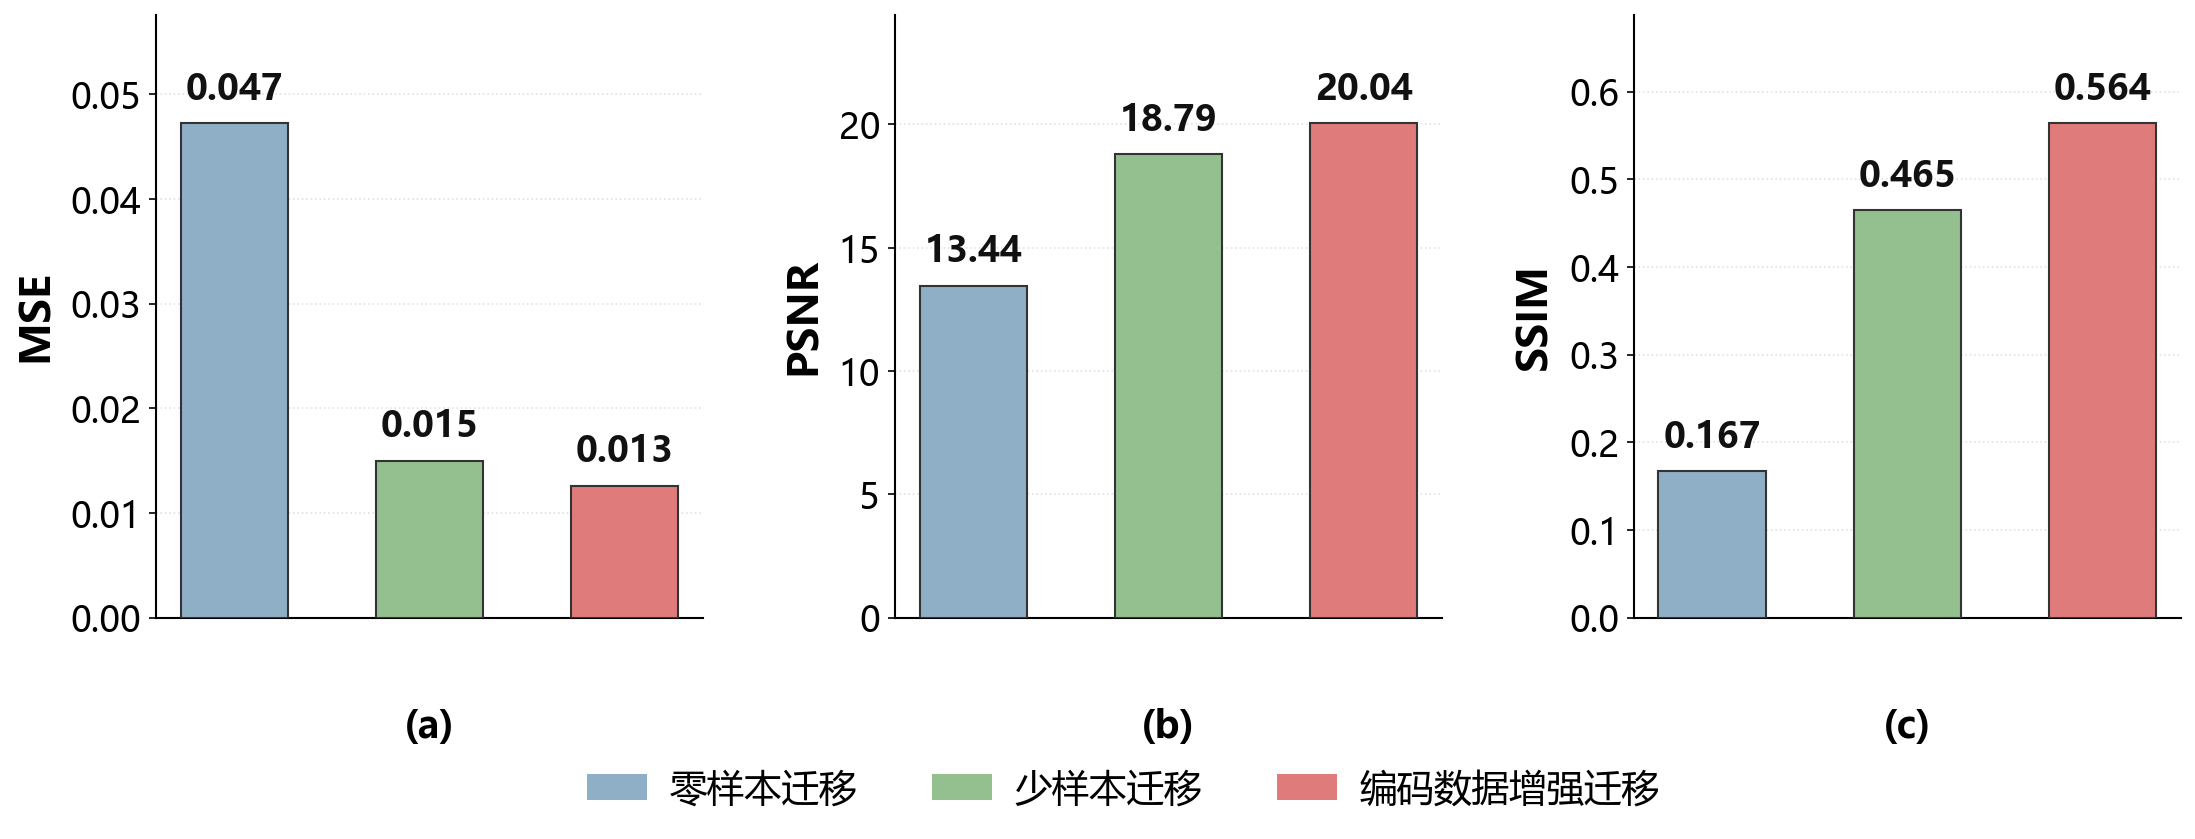

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ============================================================
# 字体设置
# ============================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# ============================================================
# 数据
# ============================================================
mse_vals  = np.array([0.0472, 0.0150, 0.0126])
psnr_vals = np.array([13.4367, 18.7872, 20.0382])
ssim_vals = np.array([0.1668, 0.4645, 0.5637])

# 配色：深色系，明度拉开，视觉层次清晰
colors = [ '#8FAFC6','#93C08E', '#E07B7B']

legend_labels = ['零样本迁移', '少样本迁移', '编码数据增强迁移']

# ============================================================
# 字号
# ============================================================
FS_YLABEL   = 20   # y 轴标签
FS_TICK     = 17   # y 轴刻度
FS_VALUE    = 17   # 柱顶数值
FS_PANEL    = 18   # (a)(b)(c)
FS_LEGEND   = 18   # 图例

# ============================================================
# 布局
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6), dpi=150)
plt.subplots_adjust(left=0.07, right=0.97, top=0.92,
                    bottom=0.25, wspace=0.35)

metrics = [
    ('MSE',  mse_vals,  '(a)'),
    ('PSNR', psnr_vals, '(b)'),
    ('SSIM', ssim_vals, '(c)'),
]

for ax, (mname, vals, panel) in zip(axes, metrics):
    x    = np.arange(len(vals))
    bars = ax.bar(
    x, vals,
    color=colors,
    width=0.55,
    edgecolor='#333333',
    linewidth=1.0,
    zorder=3
)

    # ── Y 轴范围：留柱顶数值的空间 ──
    y_max = max(vals)
    ax.set_ylim(0, y_max * 1.22)

    # ── 样式 ──
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    ax.grid(axis='y', linestyle=':', alpha=0.35, color='#AAAAAA', zorder=0)

    # ── Y 轴标签 ──
    ax.set_ylabel(mname, fontsize=FS_YLABEL, fontweight='bold', labelpad=6)

    # ── 柱顶数值：位数按指标截短 ──
    y_pad = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.025
    for b, v in zip(bars, vals):
        if mname == 'MSE':
            txt = f'{v:.3f}'     # 3 位小数
        elif mname == 'PSNR':
            txt = f'{v:.2f}'     # 2 位小数
        else:
            txt = f'{v:.3f}'     # 3 位小数
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + y_pad,
                txt,
                ha='center', va='bottom',
                fontsize=FS_VALUE, fontweight='bold', color='#111111')

    # ── 子图编号：x 轴正下方居中，脱离绘图区 ──
    ax.text(0.5, -0.15, panel,
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=FS_PANEL, fontweight='bold', color='black')

# ============================================================
# 图例：图正下方
# ============================================================
legend_patches = [Rectangle((0, 0), 1, 1, fc=c, edgecolor='none') for c in colors]
fig.legend(legend_patches, legend_labels,
           loc='lower center', ncol=3,
           fontsize=FS_LEGEND,
           frameon=False,
           bbox_to_anchor=(0.5, 0.0),
           handlelength=1.6, handletextpad=0.6,
           columnspacing=2.0)

plt.savefig('bar_metrics.pdf',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('bar_metrics.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print("Saved!")

